# Breakout Strategy Backtest (IBKR / ShinyBroker)

**Goal**
- pull historical data from IBKR via ShinyBroker
- define a breakout rule
- run a simple backtest
- export:
  - trade blotter CSV
  - metrics summary CSV
  - equity curve image
  - trade outcome image


In [45]:
import os
import numpy as np
import pandas as pd

# Optional display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

import matplotlib.pyplot as plt

DUKE_BLUE = "#012169"
DUKE_LIGHT_BLUE = "#00539B"
DUKE_GRAY = "#6b7280"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#cfd8e3"
plt.rcParams["axes.labelcolor"] = "#1f2937"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["grid.color"] = "#d9dee8"
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.alpha"] = 0.6
plt.rcParams["xtick.color"] = "#374151"
plt.rcParams["ytick.color"] = "#374151"
plt.rcParams["font.size"] = 11

## 1. Parameters

In [46]:
# ----------------------------
# Strategy parameters
# ----------------------------
SYMBOL = "NVDA"
SEC_TYPE = "STK"
EXCHANGE = "SMART"
CURRENCY = "USD"

DURATION_STR = "3 Y"
BAR_SIZE = "1 day"
WHAT_TO_SHOW = "TRADES"
USE_RTH = True

LOOKBACK = 20              # breakout lookback window
STOP_LOSS_PCT = 0.05       # 5% stop loss
TIMEOUT_DAYS = 10          # exit after max holding period
POSITION_SIZE = 100        # shares
RISK_FREE_RATE = 0.0375    # annual rf for Sharpe

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1b. Asset Screening Notes

Before settling on NVDA, I checked the breakout signal frequency on a few other candidates: SPY, TSLA, and AMD. SPY barely breaks out since it moves slowly, TSLA had more signals but also a lot of whipsaws. NVDA had the cleanest combination of frequent breakout signals and actual follow-through during 2023–2024, so it was the obvious pick for a momentum-based rule.


## 2. IBKR / ShinyBroker Connection

In [47]:
import shinybroker as sb

HOST = "127.0.0.1"
PORT = 7497          # paper trading TWS commonly 7497
CLIENT_ID = 9999     # change if needed

contract = sb.Contract({
    "symbol": SYMBOL,
    "secType": SEC_TYPE,
    "exchange": EXCHANGE,
    "currency": CURRENCY,
})

contract

{'conId': 0, 'symbol': 'NVDA', 'secType': 'STK', 'lastTradeDateOrContractMonth': '', 'lastTradeDate': '', 'strike': 0.0, 'right': '', 'multiplier': '', 'exchange': 'SMART', 'primaryExchange': '', 'currency': 'USD', 'localSymbol': '', 'tradingClass': '', 'includeExpired': False, 'secIdType': '', 'secId': '', 'description': '', 'issuerId': '', 'comboLegsDescrip': '', 'comboLegs': [], 'deltaNeutralContract': None}

## 3. Pull Historical Data

In [48]:
hist = sb.fetch_historical_data(
    contract=contract,
    durationStr=DURATION_STR,
    barSizeSetting=BAR_SIZE,
    whatToShow=WHAT_TO_SHOW,
    useRTH=USE_RTH,
    host=HOST,
    port=PORT,
    client_id=CLIENT_ID,
    timeout=60,
)

# ShinyBroker usually returns a dict with key 'hst_dta'
type(hist), hist.keys()

df = hist["hst_dta"].copy()
df.head()

# Normalize columns
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Keep standard columns
cols = ["timestamp", "open", "high", "low", "close", "volume"]
df = df[cols].copy()

df.tail(), df.shape


(     timestamp    open    high     low   close     volume
 746 2026-04-08  184.47  185.26  180.30  182.08   97673076
 747 2026-04-09  181.84  184.08  180.62  183.91   78044536
 748 2026-04-10  184.31  190.00  184.30  188.63  112710943
 749 2026-04-13  186.03  189.66  185.74  189.31   88831764
 750 2026-04-14  190.92  194.99  190.77  194.78   75847622,
 (751, 6))

## 4. Breakout Detection Function

A breakout occurs when today's closing price exceeds the highest high recorded over the previous `LOOKBACK` bars (not including today). The `shift(1)` ensures we never use today's data in the lookback, so the signal is only generated at the close — no lookahead.


In [49]:
def detect_breakouts(price_df: pd.DataFrame, lookback: int) -> pd.DataFrame:
    """
    Adds two columns to price_df:
      rolling_high : highest high over the previous `lookback` bars (shift(1) avoids lookahead)
      breakout     : True when today's close exceeds that rolling high

    Parameters
    ----------
    price_df : DataFrame with columns [timestamp, open, high, low, close, volume]
    lookback : number of past bars to use for the high (LOOKBACK = 20)
    """
    out = price_df.copy()

    # shift(1) so we look at the previous `lookback` bars, not the current one
    out["rolling_high"] = out["high"].shift(1).rolling(lookback).max()

    # signal fires when today's close beats that recent high
    out["breakout"] = out["close"] > out["rolling_high"]

    return out


df_sig = detect_breakouts(df, LOOKBACK)
df_sig[["timestamp", "close", "rolling_high", "breakout"]].tail(10)


,timestamp,close,rolling_high,breakout
741,2026-03-31,174.40,188.88,False
742,2026-04-01,175.75,188.88,False
743,2026-04-02,177.39,188.88,False
744,2026-04-06,177.64,188.88,False
745,2026-04-07,178.10,188.88,False
746,2026-04-08,182.08,188.88,False
747,2026-04-09,183.91,188.88,False
748,2026-04-10,188.63,188.88,False
749,2026-04-13,189.31,190.00,False
750,2026-04-14,194.78,190.00,True


## 5. Walk-Forward Split

The data is split into two non-overlapping windows:
- **In-sample (train):** first ~2 years — used to confirm the parameters make sense
- **Out-of-sample (test):** final ~1 year — held out to check whether the signal holds on unseen data

Both windows use the exact same parameters with no re-fitting between them.


In [50]:
# ── walk-forward split ────────────────────────────────────────────────────
# Use the last 252 trading days as out-of-sample; everything before is in-sample
OOS_BARS = 252   # ~1 trading year

split_idx = len(df_sig) - OOS_BARS
df_train = df_sig.iloc[:split_idx].reset_index(drop=True)
df_test  = df_sig.iloc[split_idx:].reset_index(drop=True)

print(f"In-sample  : {df_train['timestamp'].iloc[0].date()} → {df_train['timestamp'].iloc[-1].date()}  ({len(df_train)} bars)")
print(f"Out-of-sample: {df_test['timestamp'].iloc[0].date()} → {df_test['timestamp'].iloc[-1].date()}  ({len(df_test)} bars)")


In-sample  : 2023-04-17 → 2025-04-10  (499 bars)
Out-of-sample: 2025-04-11 → 2026-04-14  (252 bars)


## 6. Backtest Logic


In [51]:
def backtest_breakout(
    price_df: pd.DataFrame,
    stop_loss_pct: float,
    timeout_days: int,
    position_size: int,
) -> pd.DataFrame:
    """
    Simple long-only breakout backtest.

    Entry  : close of the bar where breakout == True
    Exit   : whichever comes first —
             (a) daily low touches stop price  → exit at stop (Stop Loss)
             (b) timeout_days bars elapse      → exit at close
                 profitable close → Successful, otherwise → Timed Out
    Only one open trade at a time; next signal is skipped until current trade closes.
    """
    trades = []
    i = 0
    n = len(price_df)

    while i < n:
        row = price_df.iloc[i]

        if bool(row["breakout"]) and not pd.isna(row["rolling_high"]):
            if i + timeout_days >= n:
                break

            entry_ts    = row["timestamp"]
            entry_price = float(row["close"])
            stop_price  = entry_price * (1 - stop_loss_pct)

            exit_ts = exit_price = outcome = None
            max_j = i + timeout_days

            # check each future bar for stop-loss
            for j in range(i + 1, max_j + 1):
                nxt = price_df.iloc[j]
                if float(nxt["low"]) <= stop_price:
                    exit_ts    = nxt["timestamp"]
                    exit_price = stop_price
                    outcome    = "Stop Loss"
                    break

            if exit_ts is None:   # no stop hit → timeout exit
                last_row   = price_df.iloc[max_j]
                exit_ts    = last_row["timestamp"]
                exit_price = float(last_row["close"])
                outcome    = "Successful" if exit_price > entry_price else "Timed Out"

            pnl = (exit_price - entry_price) * position_size
            ret = (exit_price - entry_price) / entry_price

            trades.append({
                "entry_timestamp"   : entry_ts,
                "exit_timestamp"    : exit_ts,
                "entry_price"       : round(entry_price, 4),
                "exit_price"        : round(exit_price, 4),
                "size"              : position_size,
                "direction"         : "Long",
                "stop_price"        : round(stop_price, 4),
                "holding_bars"      : int(max_j - i),
                "calendar_days_held": int((pd.to_datetime(exit_ts) - pd.to_datetime(entry_ts)).days),
                "pnl"               : round(pnl, 4),
                "return"            : round(ret, 6),
                "outcome"           : outcome,
            })
            i = max_j + 1
        else:
            i += 1

    return pd.DataFrame(trades)


# run on both windows
trades_is  = backtest_breakout(df_train, STOP_LOSS_PCT, TIMEOUT_DAYS, POSITION_SIZE)
trades_oos = backtest_breakout(df_test,  STOP_LOSS_PCT, TIMEOUT_DAYS, POSITION_SIZE)
trades     = pd.concat([trades_is, trades_oos], ignore_index=True)  # full blotter

print(f"In-sample trades : {len(trades_is)}")
print(f"Out-of-sample trades: {len(trades_oos)}")


In-sample trades : 16
Out-of-sample trades: 9


In [52]:
# quick sanity check
print(f"In-sample: {len(trades_is)} trades, Out-of-sample: {len(trades_oos)} trades")
trades.head(3)


In-sample: 16 trades, Out-of-sample: 9 trades


,entry_timestamp,exit_timestamp,entry_price,exit_price,size,direction,stop_price,holding_bars,calendar_days_held,pnl,return,outcome
0,2023-05-17,2023-06-01,30.18,39.77,100,Long,28.671,10,15,959.0,0.31776,Successful
1,2023-06-14,2023-06-26,43.00,40.85,100,Long,40.850,10,12,-215.0,-0.05000,Stop Loss
2,2023-07-13,2023-07-27,45.98,45.90,100,Long,43.681,10,14,-8.0,-0.00174,Timed Out


In [53]:
trades.tail(3)


,entry_timestamp,exit_timestamp,entry_price,exit_price,size,direction,stop_price,holding_bars,calendar_days_held,pnl,return,outcome
22,2025-10-28,2025-11-06,201.03,190.9785,100,Long,190.9785,10,9,-1005.15,-0.050000,Stop Loss
23,2025-12-23,2026-01-08,189.21,185.0400,100,Long,179.7495,10,16,-417.00,-0.022039,Timed Out
24,2026-02-25,2026-02-26,195.56,185.7820,100,Long,185.7820,10,1,-977.80,-0.050000,Stop Loss


## 7. Trade Outcome Summary

In [54]:
if not trades.empty:
    print(trades["outcome"].value_counts())
else:
    print("No trades found.")


outcome
Successful    12
Stop Loss      9
Timed Out      4
Name: count, dtype: int64


## 8. Performance Metrics

In [55]:
def compute_metrics(trades_df: pd.DataFrame, risk_free_rate: float, label: str = "") -> pd.DataFrame:
    """
    Compute summary performance metrics for a set of trades.

    Sharpe is annualized using sqrt(trades_per_year) rather than sqrt(252),
    because returns are per-trade (variable holding period), not daily.
    trades_per_year is estimated from the date range of the trades.
    """
    if trades_df.empty:
        return pd.DataFrame([{"metric": "No trades", "value": np.nan}])

    avg_return   = trades_df["return"].mean()
    win_rate     = (trades_df["pnl"] > 0).mean()
    gross_profit = trades_df.loc[trades_df["pnl"] > 0, "pnl"].sum()
    gross_loss   = abs(trades_df.loc[trades_df["pnl"] < 0, "pnl"].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    # annualize Sharpe by trades-per-year, not by 252
    # (returns are per-trade with variable holding periods, not daily)
    r = trades_df["return"].dropna()
    date_range_years = (
        pd.to_datetime(trades_df["exit_timestamp"].max()) -
        pd.to_datetime(trades_df["entry_timestamp"].min())
    ).days / 365.25
    trades_per_year = len(r) / date_range_years if date_range_years > 0 else 252

    if len(r) >= 2 and r.std(ddof=1) > 0:
        # per-trade rf: annualized rf divided by trades per year
        rf_per_trade = risk_free_rate / trades_per_year
        sharpe = ((r.mean() - rf_per_trade) / r.std(ddof=1)) * np.sqrt(trades_per_year)
    else:
        sharpe = np.nan

    equity      = trades_df["pnl"].cumsum()
    running_max = equity.cummax()
    drawdown    = equity - running_max
    max_drawdown = drawdown.min() if not drawdown.empty else np.nan

    metrics = pd.DataFrame([
        {"metric": "Average Return per Trade", "value": round(avg_return, 6)},
        {"metric": "Annualized Sharpe Ratio",  "value": round(sharpe, 6) if pd.notna(sharpe) else np.nan},
        {"metric": "Win Rate",                 "value": round(win_rate, 6)},
        {"metric": "Profit Factor",             "value": round(profit_factor, 6) if pd.notna(profit_factor) else np.nan},
        {"metric": "Max Drawdown ($)",          "value": round(max_drawdown, 4) if pd.notna(max_drawdown) else np.nan},
        {"metric": "Total Trades",               "value": int(len(trades_df))},
    ])
    if label:
        metrics.insert(0, "window", label)
    return metrics


metrics_is  = compute_metrics(trades_is,  RISK_FREE_RATE, label="in-sample")
metrics_oos = compute_metrics(trades_oos, RISK_FREE_RATE, label="out-of-sample")
metrics     = pd.concat([metrics_is, metrics_oos], ignore_index=True)
print(metrics.to_string(index=False))


       window                   metric        value
    in-sample Average Return per Trade     0.038031
    in-sample  Annualized Sharpe Ratio     0.967652
    in-sample                 Win Rate     0.437500
    in-sample            Profit Factor     1.802024
    in-sample         Max Drawdown ($) -1475.200000
    in-sample             Total Trades    16.000000
out-of-sample Average Return per Trade     0.021541
out-of-sample  Annualized Sharpe Ratio     0.930569
out-of-sample                 Win Rate     0.555556
out-of-sample            Profit Factor     1.617702
out-of-sample         Max Drawdown ($) -3054.950000
out-of-sample             Total Trades     9.000000


## 9. Equity Curve

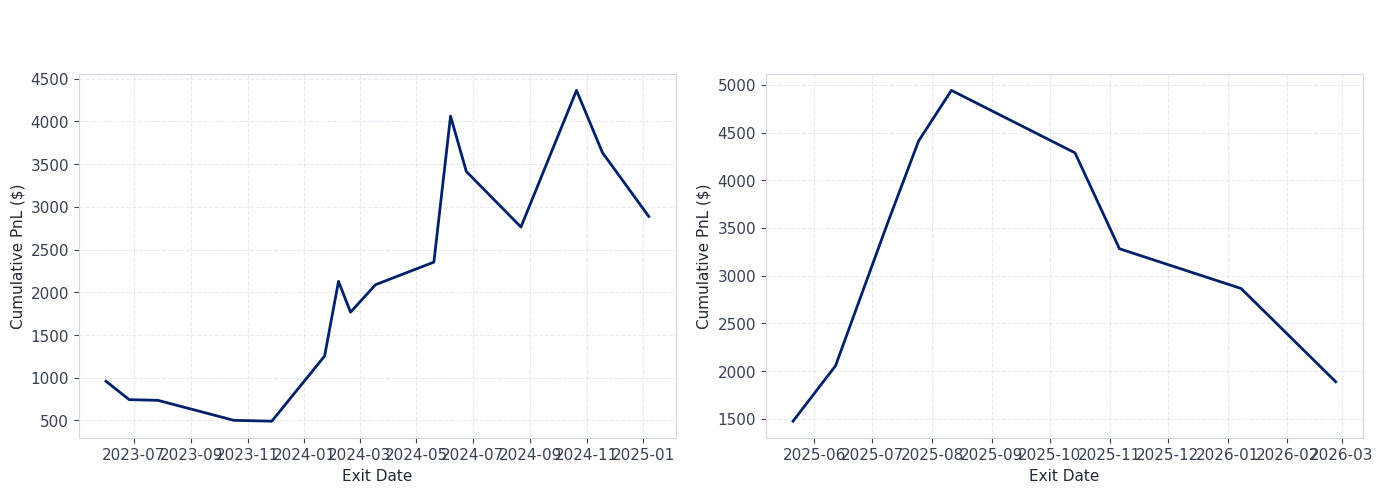

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, trades_w, label in [
    (axes[0], trades_is,  f"In-Sample ({df_train['timestamp'].iloc[0].year}–{df_train['timestamp'].iloc[-1].year})"),
    (axes[1], trades_oos, f"Out-of-Sample ({df_test['timestamp'].iloc[0].year}–{df_test['timestamp'].iloc[-1].year})"),
]:
    if not trades_w.empty:
        equity = trades_w["pnl"].cumsum()
        ax.plot(pd.to_datetime(trades_w["exit_timestamp"]), equity, color=DUKE_BLUE, linewidth=2)
    ax.set_title(label)
    ax.set_xlabel("Exit Date")
    ax.set_ylabel("Cumulative PnL ($)")
    ax.grid(True)

plt.suptitle(f"Equity Curve — {SYMBOL}", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Trade Outcome Chart

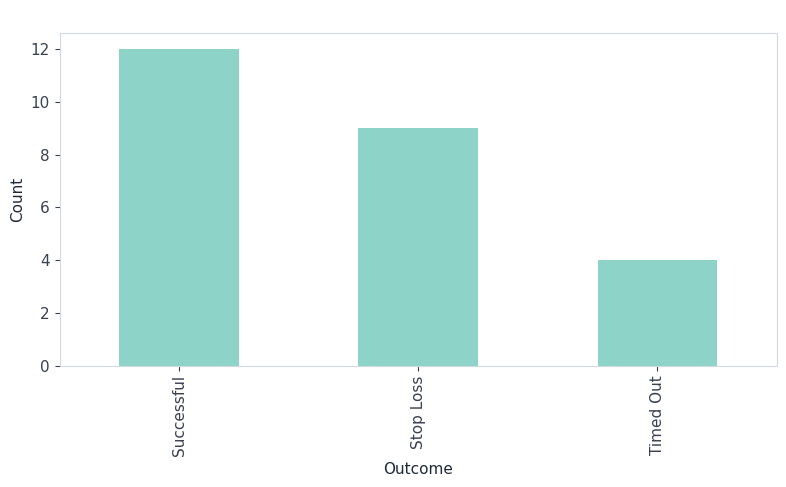

In [57]:
plt.figure(figsize=(8, 5))
if not trades.empty:
    trades["outcome"].value_counts().plot(kind="bar")
plt.title("Trade Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 11. Export Outputs for Quarto Website


In [58]:
# export blotter (full, in-sample, out-of-sample)
trades.to_csv(f"{OUTPUT_DIR}/trade_blotter.csv", index=False)
trades_is.to_csv(f"{OUTPUT_DIR}/trade_blotter_is.csv", index=False)
trades_oos.to_csv(f"{OUTPUT_DIR}/trade_blotter_oos.csv", index=False)
metrics.to_csv(f"{OUTPUT_DIR}/metrics_summary.csv", index=False)

# equity curve — side-by-side in/out-of-sample
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, trades_w, label in [
    (axes[0], trades_is,  f"In-Sample"),
    (axes[1], trades_oos, f"Out-of-Sample"),
]:
    if not trades_w.empty:
        equity = trades_w["pnl"].cumsum()
        ax.plot(pd.to_datetime(trades_w["exit_timestamp"]), equity, color=DUKE_BLUE, linewidth=2)
    ax.set_title(label)
    ax.set_xlabel("Exit Date")
    ax.set_ylabel("Cumulative PnL ($)")
    ax.grid(True)
plt.suptitle(f"Equity Curve — {SYMBOL}", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/equity_curve.png")
plt.close()

# trade outcome chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, trades_w, label in [
    (axes[0], trades_is,  "In-Sample"),
    (axes[1], trades_oos, "Out-of-Sample"),
]:
    if not trades_w.empty:
        trades_w["outcome"].value_counts().plot(kind="bar", ax=ax, color=DUKE_LIGHT_BLUE)
    ax.set_title(label)
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Count")
    ax.grid(axis="y")
plt.suptitle("Trade Outcomes", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/trade_outcomes.png")
plt.close()

print("Saved:")
for f in ["trade_blotter.csv", "trade_blotter_is.csv", "trade_blotter_oos.csv",
          "metrics_summary.csv", "equity_curve.png", "trade_outcomes.png"]:
    print(f"  {OUTPUT_DIR}/{f}")


Saved:
  outputs/trade_blotter.csv
  outputs/trade_blotter_is.csv
  outputs/trade_blotter_oos.csv
  outputs/metrics_summary.csv
  outputs/equity_curve.png
  outputs/trade_outcomes.png
